In [1]:
# 이상치 제거한 부분.

import pandas as pd
df= pd.read_csv("data_cleaned_Mon_5_45M.csv")
import matplotlib.pyplot as plt
import seaborn as sns
continuous_cols = [
    'travelDurationMinutes',
    'fare_per_minute'
]

Q1 = df[continuous_cols].quantile(0.25)
Q3 = df[continuous_cols].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


mask = ~((df[continuous_cols] < lower_bound) | (df[continuous_cols] > upper_bound)).any(axis=1)
df_cleaned = df[mask].copy()

print(f"제거 전 샘플 수: {len(df)}")
print(f"제거 후 샘플 수: {len(df_cleaned)}")
print(f"제거된 샘플 수: {len(df) - len(df_cleaned)}")

from scipy.stats import boxcox
import matplotlib.pyplot as plt
import seaborn as sns

# baseFare > 0 필터링
df_boxcox = df_cleaned[df_cleaned['baseFare'] > 0].copy()

# Box-Cox 변환 적용 -> y값은 이제 boxcox_baseFare
df_boxcox['boxcox_baseFare'], fitted_lambda = boxcox(df_boxcox['baseFare'])

# target leakage issue 를 solve 하기 위한 drop
drop_cols = ['daysBeforeFlight','baseFare', 'boxcox_baseFare', 'log_baseFare', 'fare_per_minute','via_count']

# column remove
existing = [col for col in drop_cols if col in df_boxcox.columns]
X = df_boxcox.drop(columns=existing)

# 종속변수는 제거 전 꺼내기
y = df_boxcox['boxcox_baseFare']

제거 전 샘플 수: 820332
제거 후 샘플 수: 774017
제거된 샘플 수: 46315


In [2]:
print("제거 전 X shape:", df_boxcox.shape)
print("제거 후 X shape:", X.shape)
print("X.columns에 제거 대상 있는지 확인:", set(drop_cols) & set(X.columns))  # 교집합 없어야 정상

제거 전 X shape: (774017, 20)
제거 후 X shape: (774017, 15)
X.columns에 제거 대상 있는지 확인: set()


In [3]:
from sklearn.model_selection import train_test_split
# 학습, 테스트, 검증 데이터 분리를 진행
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_temp, y_temp, test_size=0.125, random_state=42)

print(f"\n############데이터 분할 결과#############:")
print(f"Train: {X_train.shape}, Valid: {X_valid.shape}, Test: {X_test.shape}")


############데이터 분할 결과#############:
Train: (541811, 15), Valid: (77402, 15), Test: (154804, 15)


In [4]:
# 런타임 재시작 후, 버전 확인
import lightgbm as lgb
print(lgb.__version__)          # → 4.6.0 이 출력되면 OK


4.5.0


In [5]:
from sklearn.preprocessing import StandardScaler
from scipy.special import inv_boxcox
# StandardScaler 를 이용하여 정규화
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

In [6]:
#랜덤 서치로 최적의 파라미터 잡기
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
from scipy.special import inv_boxcox
from lightgbm import LGBMRegressor
from scipy.stats import randint, uniform
import numpy as np

# 1. 데이터 분할 (Train:Valid:Test = 7:1:2)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=42
)

print(f"\n############데이터 분할 결과#############:")
print(f"Train: {X_train.shape}, Valid: {X_valid.shape}, Test: {X_test.shape}")


# 3. RandomizedSearchCV 설정 (LightGBM 용)
base_model = LGBMRegressor(
    objective="regression",
    metric="rmse",
    n_jobs=-1,
    random_state=42
)

param_dist = {
    # n_estimators
    "n_estimators":    [500, 1000, 2000, 3000],
    # learning_rate
    "learning_rate":   [0.03, 0.05, 0.1, 0.2],
    # max_depth
    "max_depth":       [6, 8, 10],
    #reg_lambda
    "reg_lambda":      [1, 3, 5, 7],
    # subsample만 두고 부트스트랩 방식을 LightGBM 기본(bagging_fraction)으로 둠
    "subsample":       [0.6, 0.8, 1.0],
    # colsample_bytree: feature_fraction
    "colsample_bytree": [0.6, 0.8, 1.0]
}

# 평가 지표(RMSE)
rmse_scorer = make_scorer(
    lambda y_true, y_pred: mean_squared_error(y_true, y_pred, squared=False),
    greater_is_better=False
)

random_search = RandomizedSearchCV(
    estimator           = base_model,
    param_distributions = param_dist,
    n_iter              = 5,
    scoring             = rmse_scorer,
    cv                  = 3,
    random_state        = 42,
    n_jobs              = -1,
    verbose             = 2
)

# 4. RandomizedSearchCV 실행
random_search.fit(X_train, y_train)

# 5. 최적 모델 추출 및 성능 평가
best_model = random_search.best_estimator_

print("\n 최적 하이퍼파라미터:", random_search.best_params_)



############데이터 분할 결과#############:
Train: (541811, 15), Valid: (77402, 15), Test: (154804, 15)
Fitting 3 folds for each of 5 candidates, totalling 15 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan]
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029048 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 635
[LightGBM] [Info] Number of data points in the train set: 541811, number of used features: 15
[LightGBM] [Info] Start training from score 25.235953

 최적 하이퍼파라미터: {'subsample': 0.8, 'reg_lambda': 7, 'n_estimators': 1000, 'max_depth': 10, 'learning_rate': 0.2, 'colsample_bytree': 0.8}


In [7]:
import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error, median_absolute_error, mean_absolute_percentage_error

# 최적의 파라미터를 반영한 버전
params = {
    "n_estimators":      1000,
    "learning_rate":     0.2,
    "max_depth":         10,
    "subsample":         0.8,
    "colsample_bytree":  0.8,
    "reg_lambda":        7,
    "objective":         "regression",
    "metric":            "rmse",
    "random_state":      42,
    "n_jobs":            -1,
}

model = LGBMRegressor(**params)

# ── 콜백 정의(알 수 없는 이유로 Call Back 적용 - LightGBM 최신 버전 등 할 수 있는 노력 다 했음) ─────────────────────
early_stop = lgb.early_stopping(stopping_rounds=100, verbose=True)
log_eval   = lgb.log_evaluation(period=50)          # 50트리마다 로그

# ── 학습 ────────────────────────────────────────────
model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],   # ← 검증 세트를 반드시 넣어야 early stopping 작동
    eval_metric="rmse",
    callbacks=[early_stop, log_eval] # ← early_stop 콜백 전달
)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029076 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 635
[LightGBM] [Info] Number of data points in the train set: 541811, number of used features: 15
[LightGBM] [Info] Start training from score 25.235953
Training until validation scores don't improve for 100 rounds
[50]	valid_0's rmse: 4.32881
[100]	valid_0's rmse: 4.1981
[150]	valid_0's rmse: 4.13192
[200]	valid_0's rmse: 4.0851
[250]	valid_0's rmse: 4.04452
[300]	valid_0's rmse: 4.01446
[350]	valid_0's rmse: 3.99595
[400]	valid_0's rmse: 3.97572
[450]	valid_0's rmse: 3.9607
[500]	valid_0's rmse: 3.94645
[550]	valid_0's rmse: 3.93094
[600]	valid_0's rmse: 3.9184
[650]	valid_0's rmse: 3.90927
[700]	valid_0's rmse: 3.89816
[750]	valid_0's rmse: 3.88968
[800]	valid_0's rmse: 3.88298
[850]	valid_0's rmse: 3.87504
[900]	valid_0's rmse: 3.86

LGBMRegressor(colsample_bytree=0.8, learning_rate=0.2, max_depth=10,
              metric='rmse', n_estimators=1000, n_jobs=-1,
              objective='regression', random_state=42, reg_lambda=7,
              subsample=0.8)

In [8]:
from sklearn.metrics import mean_absolute_error, median_absolute_error, mean_absolute_percentage_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error as mse
import numpy as np
# Validation 성능
y_valid_pred = model.predict(X_valid)
mse_valid = mean_squared_error(y_valid, y_valid_pred)
r2_valid = r2_score(y_valid, y_valid_pred)
print(f"\n--Validation Set 성능(역변환이전)────────────────────────────────────────────")
print(f"MSE: {mse_valid:.4f}")
print(f"R² Score: {r2_valid:.4f}")

# ── 평가 ────────────────────────────────────────────
best_iter = model.best_iteration_
y_test_pred    = model.predict(X_test, num_iteration=best_iter)

mape = mean_absolute_percentage_error(y_test, y_test_pred)
mse_val = mse(y_test, y_test_pred)   # 기본값 squared=True
rmse    = np.sqrt(mse_val)
r2   = r2_score(y_test, y_test_pred)

print(f"\n--Test Set 성능(역변환이전)────────────────────────────────────────────")
print(f"MSE:  {mse_val:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R^2:  {r2:.2f}")
print(f"MAPE: {mape:.2f}%")

# R-squared와 RMSE는 준수한데 MAPE는 왜 저런 값이 나오지?했는데 역변환을 안했습니다.


--Validation Set 성능(역변환이전)────────────────────────────────────────────
MSE: 14.8485
R² Score: 0.7569

--Test Set 성능(역변환이전)────────────────────────────────────────────
MSE:  14.80
RMSE: 3.85
R^2:  0.75
MAPE: 20511650808481.43%


In [9]:
#  역변환후

y_test_pred_original = inv_boxcox(y_test_pred, fitted_lambda)
y_test_original = df_boxcox.loc[y_test.index, 'baseFare']
mse_original = mean_squared_error(y_test_original, y_test_pred_original)
r2_original = r2_score(y_test_original, y_test_pred_original)
mae = mean_absolute_error(y_test_original, y_test_pred_original)
medae = median_absolute_error(y_test_original, y_test_pred_original)
mape = mean_absolute_percentage_error(y_test_original, y_test_pred_original)

print(f"\n--Test Set 성능(역변환이후)────────────────────────────────────────────")
print(f"MSE: {mse_original:.2f}")
print(f"R² Score: {r2_original:.2f}")
print(f"MAE: {mae:.2f}")
print(f"Median AE: {medae:.2f}")
print(f"MAPE: {mape*100:.2f}%")


--Test Set 성능(역변환이후)────────────────────────────────────────────
MSE: 7495.22
R² Score: 0.72
MAE: 61.45
Median AE: 43.86
MAPE: 36.77%


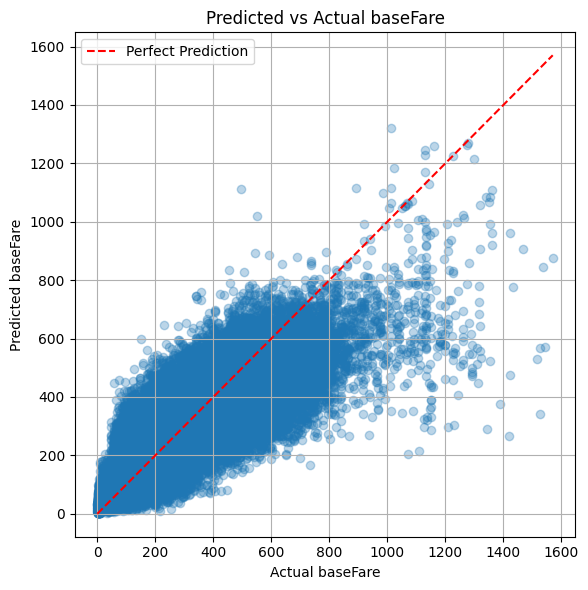

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test_original, y_test_pred_original, alpha=0.3)
plt.plot([y_test_original.min(), y_test_original.max()],
         [y_test_original.min(), y_test_original.max()],
         'r--', label='Perfect Prediction')

plt.xlabel('Actual baseFare')
plt.ylabel('Predicted baseFare')
plt.title('Predicted vs Actual baseFare')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


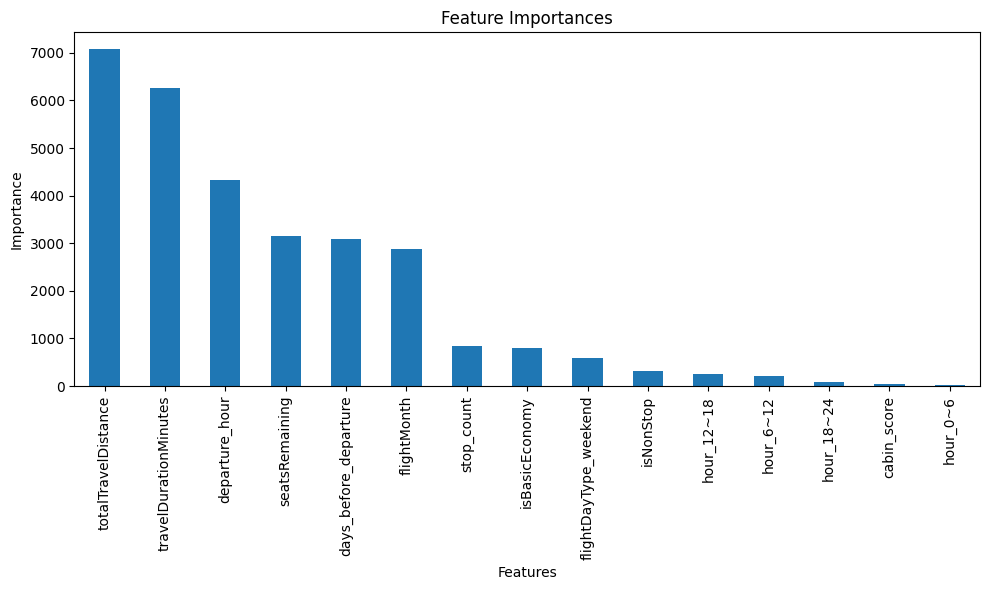

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# 1) Feature importance 배열 가져오기
importances = model.feature_importances_
features = X_train.columns  # 학습에 사용한 DataFrame의 컬럼명

# 2) Pandas Series로 변환해서 정렬
fi_series = pd.Series(importances, index=features).sort_values(ascending=False)

# 3) 막대그래프로 시각화
plt.figure(figsize=(10, 6))
fi_series.plot(kind="bar")
plt.title("Feature Importances")
plt.ylabel("Importance")
plt.xlabel("Features")
plt.tight_layout()
plt.show()



 SHAP 분석 중...


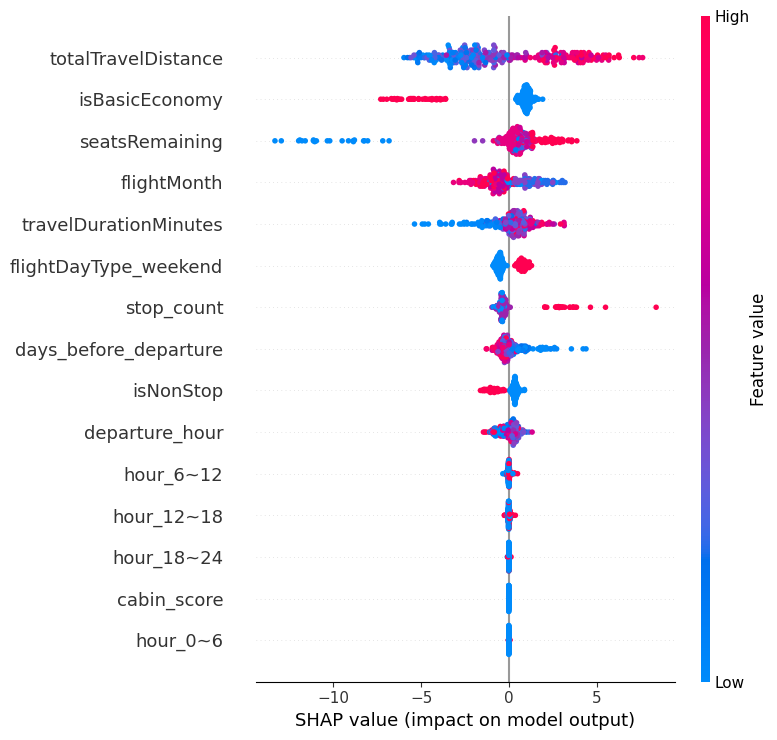

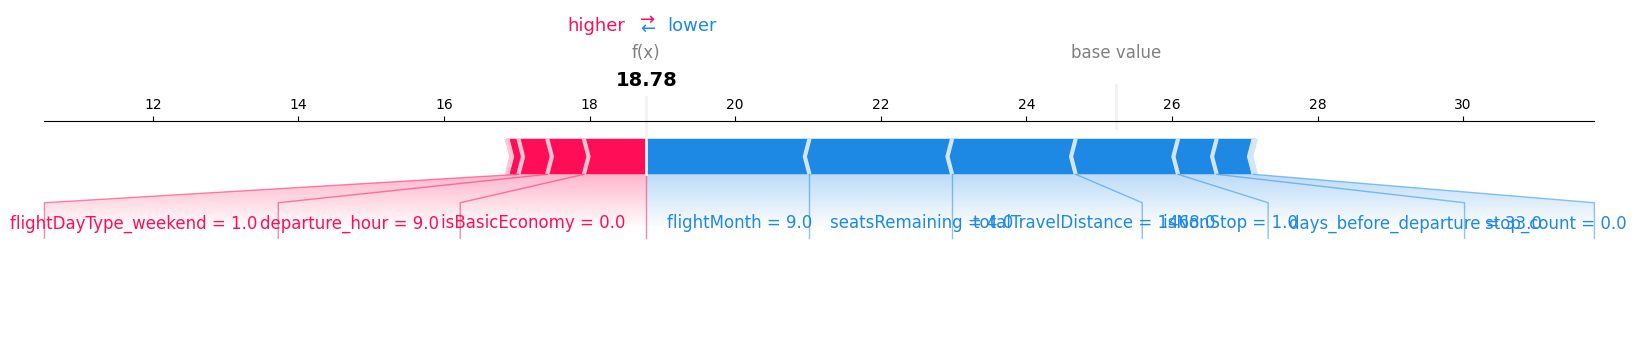

In [15]:
import shap
import lightgbm as lgb
import matplotlib.pyplot as plt

# SHAP explainer 생성
explainer = shap.TreeExplainer(model)

# 계산 시간 단축을 위해 300개 샘플만 사용
X_sample = X_test.sample(300, random_state=42)
shap_values = explainer.shap_values(X_sample)

# SHAP 요약 플롯
shap.summary_plot(shap_values, X_sample, feature_names=X.columns)

# SHAP Force Plot (개별 예측 설명)
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0], X_sample.iloc[0], matplotlib=True)